# Optimizing Feature Selection using Simulated Annealing

## Introduction

In my current role, I've developed and deployed several predictive models spanning the entire student lifecycle. These models estimate outcomes such as the likelihood that a prospective student will apply or enroll, or that an enrolled student will retain or graduate. Regardless of the specific outcome, one of the most challenging aspects is determining which features to include in the model.

Feature selection typically requires extensive exploratory data analysis to assess the relationship between each feature and the target variable. It also involves a considerable amount of trial and error. This process is time-consuming, and it’s easy to overlook meaningful interactions—especially as the number of features increases.

I've used evolutionary algorithms in the past to optimize other [solutions](https://htmlpreview.github.io/?https://github.com/jason-hanser/block-schedule/blob/master/block-schedule-walkthrough-p1.html) and figured I could use a similar approach to automate this process. In this project, I built a program that uses simulated annealing to optimize feature selection for a student retention model. The algorithm evaluates both main effects and two-way interaction terms. The goal is to streamline the modeling process and improve overall model performance through more efficient, automated feature selection.


## Data & Packages

To begin, we’ll load the necessary packages and the dataset used for modeling. Aside from some light pre-processing, the data has already been cleaned, as detailing that workflow is outside the scope of this post. As with other higher education projects shared on this site, the dataset consists of student-level records and is not publicly available due to privacy concerns.

The dataset includes four years of enrollment and retention data, totaling approximately 100,000 rows. It contains around 40 candidate variables such as cumulative GPA, prior term GPA, sex, residency status, college or school, and others.

In [1]:
## loading libraries

import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib.pyplot as plt
import random  

from itertools             import combinations
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score
from sklearn.metrics       import f1_score

## loading data

df_retain = pd.read_csv("clean_data.csv")


## basic set of variables to use 

current_variables  = ['IN_RESD_N', 'IN_PRIOR_TERM_GPA', 'IN_CUML_GPA', 'IN_RESD_N:IN_CUML_GPA']



## Functions

This project will require multiple functions. 

First, we need to create a function that will modify the slate of variables we are using in each iteration. The function below takes our current slate of variables and the full list of potential variables. The function then adds or removes a term at random. When adding a term, the function will either add a main effect from the full list of potential variables. Or, the function will create a two-way interaction from the variables currently being used. When removing a term, we remove the selected term as well as any dependent interaction terms. For example, if we remove IN_RESD_N - we would also remove IN_RESD_N:IN_CUML_GPA. This framework could be extended to include three-way interactions, but this implementation is limited to two-way interactions.

In [2]:
def change_variables(vars, all_vars, min_terms = 5, max_terms = 35):

    temp_all_main_effects   = sorted(all_vars)
    temp_curr_main_effects  = sorted([x for x in vars if x in temp_all_main_effects])
    temp_2_way_interactions = [':'.join(x) for x in combinations(temp_curr_main_effects, 2)]
        
    ## randomly removing a variable(s) (& any higher order terms that rely on that variable)
    if (random.random() < 0.50 and len(vars) > min_terms) or len(vars) >= max_terms:
        
        ## randomly removing a term & any higher order terms that rely on that variable
        
        temp_subtract_var = random.choice(vars)
        temp_subtract_var = [temp_subtract_var] + [x for x in vars if all(y in x for y in temp_subtract_var.split(':'))]
        temp_subtract_var = list(set(temp_subtract_var))

        vars = [x for x in vars if x not in temp_subtract_var]
        
            
    ## randomly adding variable(s)
    else:
        
        ## adding a main effect
        if (random.random() < 0.75 and len(set(temp_all_main_effects) - set(vars)) > 0):
            
            temp_add_var = random.choice(list(set(temp_all_main_effects) - set(vars)))
        
            vars.append(temp_add_var)
        
        ## adding a two way interction from the current main effects in vars
        elif (len(set(temp_2_way_interactions) - set(vars)) > 0):
            
            temp_add_var = random.choice(list(set(temp_2_way_interactions) - set(vars)))  
                        
            vars.append(temp_add_var)
                
    ## returning the new variables
    
    return vars
            

Next, we need a function that prepares the dataset based on the selected slate of variables. This function takes two inputs: a data frame and a list of variables, which may include interaction terms (e.g., "IN_RESD_N:IN_PRIOR_TERM_DWF"). It returns a data frame containing the corresponding values for each specified term. During this process, the function scales all numeric main effects to minimize the likelihood of a convergence issue. To account for potential temporal effects—such as grade inflation—scaling is performed within each academic term. After scaling, the function constructs any necessary interaction terms based on the transformed features.

In [3]:

def pre_process(data, vars):
    
    ## getting non input columns
    temp_keep_cols = [x for x in data.columns if x.startswith('KEEP_')]
    temp_out_cols  = [x for x in data.columns if x.startswith('OUT_')]

    ## scaling numerical variables by focal term
    
    temp_numeric_cols = [x for x in vars if ':' not in x]
    temp_numeric_cols = [x for x in temp_numeric_cols if data[x].nunique() > 2]
        
    if len(temp_numeric_cols) > 0:

        def scale_data_by_group(data):        
            
            data_scaled = data.copy()
            
            data_scaled[temp_numeric_cols] = StandardScaler().fit_transform(data[temp_numeric_cols])
        
            return data_scaled
    
        data_scaled = data.groupby('KEEP_TERM_DESC', group_keys = False).apply(scale_data_by_group, include_groups = False)
    
        data[temp_numeric_cols] = data_scaled[temp_numeric_cols]
    
    
    ## splitting out interaction terms
    
    temp_interactions = [x for x in vars if ':' in x]

    if len(temp_interactions) > 0:

        ## calculating interaction values    
        for i in temp_interactions:
            
            temp_main_effects = i.split(':')
            
            data[i] = data[temp_main_effects].prod(1)
               
        
    ## putting the data frame back together and returning it
    
    data = data[temp_keep_cols + vars + temp_out_cols]
    return data
    
    

The next function trains a logistic regression model using the processed dataset and a specified list of features. It applies a standard five-fold cross-validation procedure and calculates two performance metrics for each fold: AUC and F1 score.

Although both metrics are computed, AUC is used as the primary scoring criterion. Since the goal is to rank students by their relative likelihood of being retained, AUC is a more appropriate measure in this context.

In [4]:
def model_data(data, vars):
         
    ## initilizing df to store fit statistics
        
    df_model_fit = pd.DataFrame()
                     
    ## creating training data set and splitting it into five folds for cross-validation 
    
    train_data = data.loc[data['KEEP_MODEL_SPLIT'] == "TRAIN"]
    train_data = train_data.reset_index()
    train_data['CV_FOLD'] = train_data.index % 5
    
    ## cross validation loop
    for i in range(5):
    
        ## prepping training data 
        temp_train = train_data.loc[train_data['CV_FOLD'] != i]

        temp_train = temp_train.sample(n = 20000, weights = 'KEEP_TERM_WEIGHT', replace = True)
        temp_train = temp_train.reset_index()

        temp_train_x = temp_train[vars]
        temp_train_y = temp_train['OUT_RETAIN']

        ## prepping cross-validation data
        temp_valid = train_data.loc[train_data['CV_FOLD'] == i]        

        temp_valid_x = temp_valid[vars]
        temp_valid_y = temp_valid['OUT_RETAIN']
                        
        ## fitting data to model & getting predictions
        
        temp_model = LogisticRegression(max_iter = 1000)
        temp_model.fit(temp_train_x, temp_train_y)
            
        temp_preds = temp_model.predict_proba(temp_valid_x)[:, 1]
            
        ## calculating fit statistics
        
        temp_results = pd.DataFrame()

        temp_results['CV_FOLD'] = [i]
        temp_results['AUC']     = [roc_auc_score(temp_valid_y, temp_preds)]
        temp_results['F1']      = [f1_score(temp_valid_y, temp_preds >= 0.5)]

        ## clean up
        
        df_model_fit = pd.concat([df_model_fit, temp_results])
          
    ## returning the model fit stats
    
    return df_model_fit      
     

The final function implements the simulated annealing algorithm. It takes the modeling dataset and an initial set of variables as input. The process begins by fitting a model using the initial feature slate, then enters a loop where the variable set is modified at each iteration.

After fitting a new model, its AUC score is compared to that of the current model. If the new model performs better, it is accepted. If it performs worse, it is accepted probabilistically based on the current temperature and the difference in model performance. This allows the algorithm to occasionally accept inferior models in order to escape local minima.

When the temperature is high, the algorithm is more likely to accept worse-performing models, promoting exploration. As the temperature decreases, the probability of accepting suboptimal solutions drops, shifting the focus toward exploitation.

This balance between exploration and exploitation is controlled by three parameters: the starting temperature, the cooling rate, and the number of iterations. A higher starting temperature and slower cooling rate favor exploration, while a lower starting temperature, faster cooling rate, or larger number of iterations shift the focus toward exploitation. There are general best practices for tuning these parameters, but the optimal values depend on the specific dataset and problem being solved.


In [5]:

def simulated_annealing(data, init_vars, start_temp = 100, cooling_rate = 0.99, max_iter = 1000):
    
    ############   
    ## SET UP ##
    ############
    
    random.seed(1850)
    
    model_scores = pd.DataFrame()
    
    all_vars     = [x for x in data.columns if x.startswith('IN_')]
    
    current_df   = data.copy()
    current_vars = init_vars.copy()
    
    temp         = start_temp
    

    ###################
    ## INITIAL MODEL ##
    ###################

    ## modeling data
    
    current_df    = pre_process(data = current_df, vars = current_vars)
    df_model_fit  = model_data(data  = current_df, vars = current_vars)
    
    df_model_fit['iter'] = 0        
    current_score        = sum(df_model_fit['AUC'])/len(df_model_fit['AUC'])*100
    
    model_scores = pd.concat([model_scores, df_model_fit])
        
    
    ##############################
    ## SIMULATED ANNEALING LOOP ##
    ##############################
    
    for i in range(1, max_iter+1):
           
        ## init data & getting new set of features
        
        new_df        = data.copy()
        new_variables = current_vars.copy()
        
        new_variables = change_variables(vars = new_variables, all_vars = all_vars, max_terms = 30)

        ## modeling the data
        
        new_df       = pre_process(data = new_df, vars = new_variables)   
        df_model_fit = model_data(data = new_df, vars = new_variables)
        
        df_model_fit['iter'] = i      
        new_score            = df_model_fit['AUC'].mean()*100
        
        model_scores = pd.concat([model_scores, df_model_fit])
        
        ## accepting the new slate of features IF they are better OR probabilistically if they are worse
        
        if new_score > current_score or np.exp(-(current_score - new_score)/temp) > random.random():
            
            current_vars  = new_variables.copy()
            current_score = new_score
                        
        ## clean up & reducing the temperature
        
        temp = temp*cooling_rate
            
    
    ## returning the variables and some fit statistics
    
    return current_vars, model_scores
    

And having now finished the functions above, we can run the program and extract the results. 

In [6]:
## Running the simulated annealing program

random.seed(125)
SA_results = simulated_annealing(data = df_retain, init_vars = current_variables, start_temp = 20, cooling_rate = 0.99, max_iter = 1500)

## extracting final variables and fit statistics

SA_variables = SA_results[0]
SA_fit_stats = SA_results[1]


## Results

The plot below shows the average AUC across the five cross-validation folds over 1,500 iterations of the simulated annealing algorithm. During the first 400 iterations, AUC increased rapidly and erratically, reflecting the algorithm's exploratory behavior at higher temperatures. After that, improvement became more gradual, and performance eventually plateaued.

In hindsight, fewer iterations may have been sufficient, but the extended run provides a clearer picture of the algorithm’s convergence behavior.

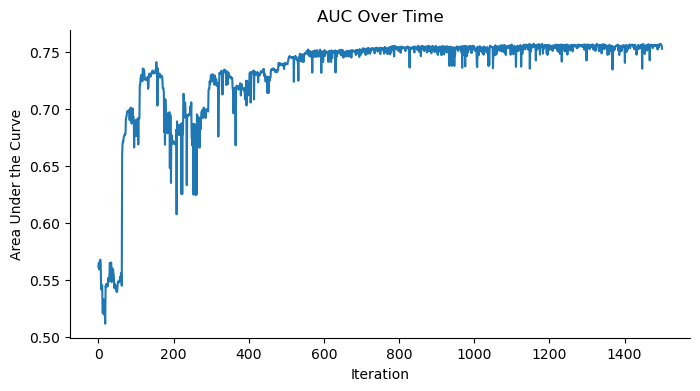

In [7]:
## aggregating results
temp_fit = (SA_fit_stats
            .groupby('iter')
            .agg(AUC = ('AUC', 'mean'),
                 F1  = ('F1',  'mean'))
            .reset_index()
            )

## plotting results
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data = temp_fit, x = 'iter', y = 'AUC')
plt.title("AUC Over Time")
plt.xlabel("Iteration")
plt.ylabel("Area Under the Curve")
sns.despine()

Below is our "optimized" slate of features. While simulated annealing is billed an optimization algorithm, it doesn't necessarily guarantee an optimal solution - just near-optimal solution. As such, I may want to experiment with this list of features a bit. That said, this provides a strong starting point and eliminates a significant amount of manual work.

In [8]:
print(SA_variables)

['IN_CURR_HOURS', 'IN_PRIOR_TERM_GPA', 'IN_CUML_4000_LEVEL', 'IN_ON_CAMPUS_Y', 'IN_NEW_STUDENT_Y', 'IN_CURR_COLLEGE_College of Nursing', 'IN_CUML_GPA', 'IN_CUML_HOURS_EARNED', 'IN_HS_GPA', 'IN_CURR_COLLEGE_College of Humanities', 'IN_ACT_SCORE', 'IN_CUML_GPA:IN_CUML_HOURS_EARNED', 'IN_CURR_COLLEGE_College of Science', 'IN_CUML_CAPSTONE_Y', 'IN_CURR_COLLEGE_College of Social & Behavioral Science', 'IN_HS_GPA:IN_NEW_STUDENT_Y', 'IN_PRIOR_TERM_DWF', 'IN_CURR_COLLEGE_School for Cultural & Social Transformation', 'IN_CUML_4000_LEVEL:IN_CURR_HOURS', 'IN_DEPOSIT_DATE', 'IN_UG_GPA', 'IN_CUML_HOURS_EARNED:IN_CURR_COLLEGE_College of Social & Behavioral Science', 'IN_CUML_HOURS_EARNED:IN_PRIOR_TERM_DWF', 'IN_CURR_COLLEGE_Undergraduate Studies', 'IN_TRANS_HOURS', 'IN_CURR_COLLEGE_College of Architecture + Planning', 'IN_CURR_COLLEGE_School of Medicine', 'IN_CURR_COLLEGE_School of Business']


Next, we can apply the "optimized" slate of features to our test data to examine its performance on new data.

In [9]:
## processing data

df_new = pre_process(data = df_retain, vars = SA_variables)

## splitting out training data and re-sampling it

train_data = df_new.loc[df_new['KEEP_MODEL_SPLIT'] == "TRAIN"]
train_data = train_data.sample(n = 100000, weights = 'KEEP_TERM_WEIGHT', replace = True)
train_data = train_data.reset_index()

## seperating training and test data

temp_train_x = train_data[SA_variables]
temp_train_y = train_data['OUT_RETAIN'].squeeze()

temp_test_x  = df_new.loc[df_new['KEEP_MODEL_SPLIT'] == "TEST", SA_variables]
temp_test_y  = df_new.loc[df_new['KEEP_MODEL_SPLIT'] == "TEST", 'OUT_RETAIN'].squeeze()

## fitting model to data and getting predictions

temp_model = LogisticRegression(max_iter = 1000)
temp_model.fit(temp_train_x, temp_train_y)    

temp_preds = temp_model.predict_proba(temp_test_x)[:, 1]


Our final model had an AUC of 0.76 and an F1 score of 0.94 on our test data. The relatively high F1 score compared to AUC is likely the result of our imbalanced data - roughly 90% of students retain. While an AUC of 0.76 may not seem particularly impressive, it's not bad considering the nature of student retention. The reality is that students drop out for a variety of reasons (e.g. death of a family member, personal health reasons, their boyfriend is transferring to another school), but we typically only have academic indicators at our disposal. 

In [10]:
## fit stats
print("Prediction Performance")
print(f"AUC-ROC:    {round(roc_auc_score(temp_test_y, temp_preds), 3)}")
print(f"F1 Score:   {round(f1_score(temp_test_y, temp_preds >= 0.5), 3)}")

Prediction Performance
AUC-ROC:    0.764
F1 Score:   0.942


# Conclusion & Next Steps

Overall, this approach worked well. While the code could be further generalized to support a wider range of modeling problems, that’s beyond the scope of this write-up. As it stands, the framework provides a practical and flexible way to automate feature selection and improve model performance with relatively little manual work.